# TP53 Mutation Predictor — Final Report

**Predicting TP53 mutation status and mutation type from bulk RNA-seq, with biologically-informed graph priors and external validation on TCGA primary tumours.**

---

## Abstract

*TP53* is the most frequently mutated gene in human cancer. We built a fully reproducible pipeline that predicts:
- **Task 1** — TP53 mutation **status** (binary: mutant vs wild-type)
- **Task 2** — TP53 mutation **type** (multiclass: missense vs truncating vs other)

from bulk RNA-seq expression profiles, using the Cancer Cell Line Encyclopedia (CCLE / DepMap 24Q4, n = 1,673 cell lines) for training and the TCGA pan-cancer atlas (n = 8,424 primary tumours) for external validation.

**Headline findings:**
1. **XGBoost on top-2,000 highly variable genes is the strongest model** for binary status (CCLE OOF F1 = 0.875, ROC-AUC = 0.906).
2. **It transfers respectably to TCGA** (ROC-AUC = 0.806 with per-cohort z-score normalisation; F1 = 0.641 after threshold calibration).
3. **The model independently rediscovers canonical TP53 biology**: SHAP identifies CDKN1A (p21) as the dominant predictor, and a hypergeometric test confirms TP53 pathway genes are enriched among top-K SHAP features at **52.6× (p = 1.07 × 10⁻⁸)** for K = 10.
4. **Graph neural networks (GCN, GAT) improve with better design** but remain weaker than XGBoost on within-cohort metrics, and **fail external transfer to TCGA** (AUC ≈ 0.40, model collapses) due to BatchNorm distribution shift + raw-feature scale mismatch — an honest negative finding.
5. **Mutation TYPE is intrinsically harder than mutation STATUS** to predict from bulk transcriptome — Logistic Regression's macro-F1 of 0.37 is the best balanced metric — consistent with the loss-of-function biology of TP53.

## Table of contents

1. [Background](#1-background)
2. [Data](#2-data)
3. [Methods](#3-methods)
4. [Task 1 — Binary classification](#4-task-1)
    - 4.1 Top-2,000 HVG selection
    - 4.2 XGBoost baseline
    - 4.3 Plotting ROC, PR, confusion matrix
    - 4.4 Graph construction (Spearman + STRING + hybrid)
    - 4.5 GCN and GAT — model comparison
    - 4.6 Threshold calibration on TCGA
    - 4.7 SHAP interpretability
    - 4.8 Formal pathway enrichment
    - 4.9 TCGA external validation
    - 4.10 Why GNNs fail to transfer (honest negative result)
5. [Task 2 — Multiclass mutation type](#5-task-2)
    - 5.1 Class distribution
    - 5.2 Models
    - 5.3 Per-class metrics + confusion matrices
    - 5.4 Per-class top genes
6. [Conclusions](#6-conclusions)
7. [References](#7-references)

### Setup — imports and paths

All code cells in this notebook load results from `../data/processed/` (relative to the notebook), so it can be re-run end-to-end on any machine where the project is checked out and the conda env (`tp53-predictor`) is active.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display, Markdown
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve,
)
from scipy.stats import hypergeom, fisher_exact

PROC = Path('..') / 'data' / 'processed'
PLOTS = PROC / 'plots'
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', font_scale=1.0)
print('Project root :', PROC.resolve().parent.parent)
print('Processed dir:', PROC.resolve())

Project root : /mnt/beegfsstudents/home/3415496/tp53-mutation-predictor
Processed dir: /mnt/beegfsstudents/home/3415496/tp53-mutation-predictor/data/processed


## 1. Background

*TP53* ("guardian of the genome") sits at the apex of the cellular stress response. When activated by DNA damage, oncogene signalling, or hypoxia, p53 induces a transcriptional program that arrests the cell cycle (via p21 / *CDKN1A*), drives apoptosis (PUMA / *BBC3*, *BAX*, *FAS*), or initiates DNA-repair / senescence cascades.

Loss of TP53 function eliminates these brakes and is observed in about half of all human cancers — making it both the most frequently mutated gene in cancer and one of the most pharmacologically un-targetable.

### Why try to predict TP53 mutation from gene expression?

Because TP53 is a *transcription factor*, mutations should leave a **detectable footprint** in the downstream gene-expression program. If we can read this footprint from bulk RNA-seq, we get:
- A way to infer mutation status when DNA sequencing is unavailable.
- A clean benchmark for whether modern ML methods recover the biology.
- A controlled testbed for graph-based models that use protein-protein interaction priors.

### Two questions, two tasks

| Task | Question | Output |
|---|---|---|
| **Task 1** | Is this cell line / tumour TP53-**mutant**? | binary {WT, mutant} |
| **Task 2** | If TP53-mutant, **which type** of mutation? | multiclass {Missense, Truncating, Other} |

## 2. Data

| Cohort | Source | Samples | Genes | TP53 mutant rate |
|---|---|---:|---:|---:|
| **CCLE** (training) | DepMap Public 24Q4 | 1,673 cell lines | 19,193 protein-coding | 58.9 % |
| **TCGA** (external) | UCSC Xena PanCanAtlas | 8,424 primary tumours | 1,851 (overlap with CCLE top-2k) | 36.5 % |

The 22-percentage-point gap reflects the well-documented **selection bias from immortalisation** — TP53-mutant clones are over-represented in cell lines.

In [2]:
# Quick summary of the two cohorts (read from already-processed files)
ccle_xgb = pd.read_csv(PROC / 'xgb_baseline_oof_preds.csv', index_col=0)
tcga_xgb = pd.read_csv(PROC / 'tcga_xgb_oof_preds.csv')

summary = pd.DataFrame({
    'samples': [len(ccle_xgb), len(tcga_xgb)],
    'TP53 mutant': [int(ccle_xgb['tp53_binary'].sum()), int(tcga_xgb['tp53_binary'].sum())],
    'TP53 mutant rate': [ccle_xgb['tp53_binary'].mean(), tcga_xgb['tp53_binary'].mean()],
}, index=['CCLE (training)', 'TCGA (external)'])
summary.style.format({'TP53 mutant rate': '{:.1%}', 'samples': '{:,d}', 'TP53 mutant': '{:,d}'})

,samples,TP53 mutant,TP53 mutant rate
CCLE (training),"1,673",986,58.9%
TCGA (external),"8,424","3,077",36.5%


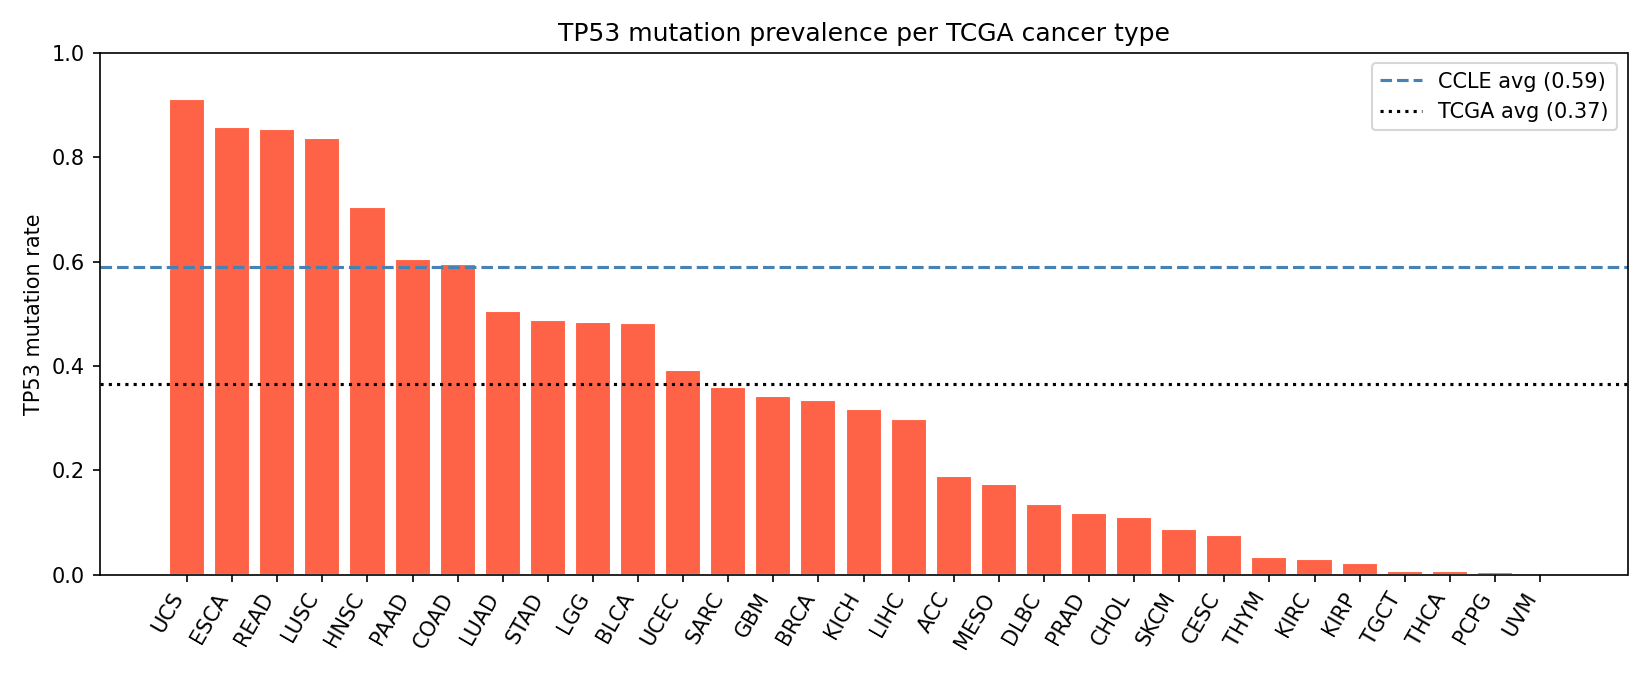

In [3]:
# Per-cancer-type TP53 prevalence in TCGA — recapitulates the textbook landscape
display(Image(str(PLOTS / 'domain' / 'tp53_prevalence_per_type.png')))

**Sanity check** — top mutated cancers (UCS, ESCA, READ, LUSC, HNSC) match published TP53 mutation landscapes; cancers where TP53 is rarely a driver (THCA, PCPG, UVM) sit near zero. Labels are clean.

**Cross-cohort PCA** — combined CCLE + TCGA on shared 1,851 genes (per-cohort z-scored): cohorts overlap substantially in PC1-PC2, which is *necessary* for cross-cohort transfer (and is why XGBoost transfers later).

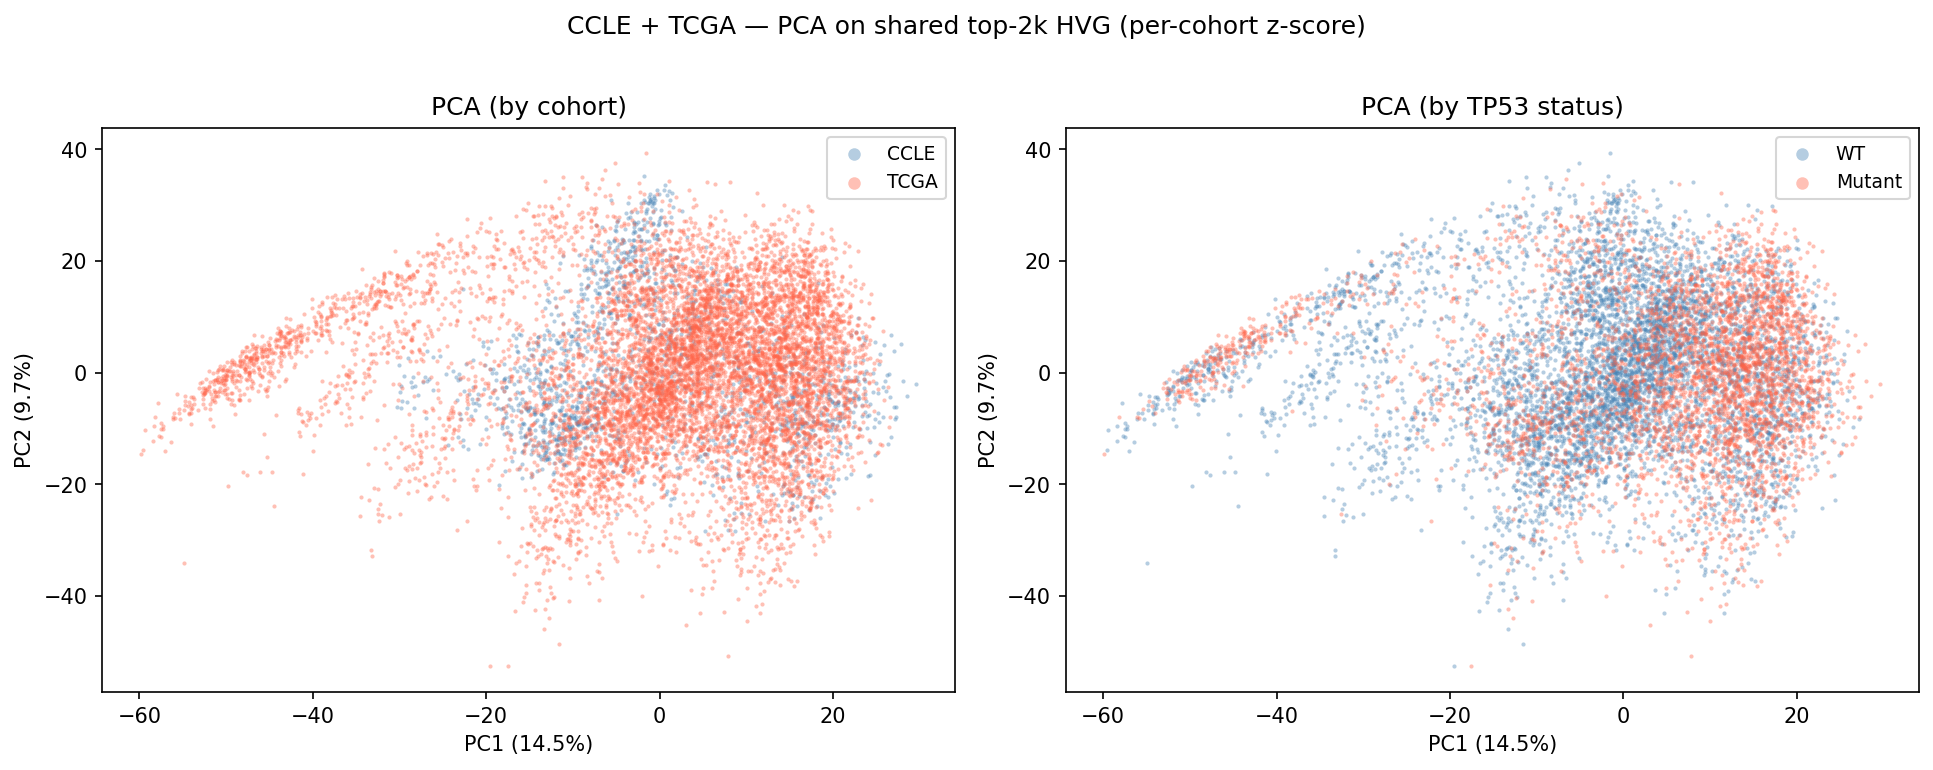

In [4]:
display(Image(str(PLOTS / 'domain' / 'pca_combined.png')))

## 3. Methods (in plain language)

**Feature selection** — we keep the top **2,000 most variable genes** out of 19,193 (variance computed across the CCLE cohort). This focuses the model on genes that actually carry signal and reduces noise + compute. The same 2,000 genes are used by every model, so comparisons are fair.

**Cross-validation** — 5-fold stratified cross-validation (preserves TP53 mutant ratio in each fold). Fold assignments are computed once and shared across **all** models so that within-cohort comparisons are exactly aligned.

**Feature scaling** — z-scored *per fold* using only training-fold statistics for GNN node features (avoids leakage). For external validation, we z-score per cohort (CCLE to its own stats, TCGA to its own).

**Models we try (Task 1 binary):**
- **XGBoost** — gradient-boosted trees on the 2,000 features (the tabular baseline).
- **GCN** (Graph Convolutional Network) — runs message passing over a gene-gene graph.
- **GAT** (Graph Attention Network) — same idea as GCN but learns attention weights for each neighbour.

**Graph topologies we test for the GNNs (5 variants):**
- Spearman co-expression at three thresholds (`|ρ| ≥ 0.5`, `|ρ| ≥ 0.7`, top-10 neighbours per gene)
- STRING physical PPI (high-confidence, score ≥ 700)
- Hybrid (union of STRING and Spearman ≥ 0.5)

**Models we try (Task 2 multiclass):** XGBoost (multi-class softmax) and Logistic Regression (multinomial L2).

**Hardware** — Bocconi HPC, partition `stud`, single A100 80 GB GPU. Total compute for the full pipeline: ~6 hours wall-clock.

## 4. Task 1 — Binary mutation status

### 4.1 Selecting the top-2,000 highly variable genes

We pick the 2,000 genes with the largest variance across CCLE — these are the genes whose expression varies most across samples and therefore carry the most discriminative signal.

In [5]:
# Top-2k HVG (precomputed; reproducible from src/train_xgb.py: select_top_variable_genes)
top_genes = pd.read_csv(PROC / 'top_genes.csv')['gene'].tolist()
print(f'Top-{len(top_genes)} highly variable genes selected')
print('First 10:', [g.split(' (')[0] for g in top_genes[:10]])

Top-2000 highly variable genes selected
First 10: ['KRT19', 'SPARC', 'C19orf33', 'FN1', 'TGFBI', 'RPS4Y1', 'UCHL1', 'KRT8', 'VIM', 'KRT7']


### 4.2 XGBoost baseline

We train an XGBoost classifier with sensible defaults under 5-fold stratified cross-validation. Training is fast (~2 min on CPU) so the script `src/train_xgb.py` was run from the command line; here we just load the saved metrics and out-of-fold (OOF) predictions for analysis.

**Reference code (`src/train_xgb.py`):**

```python
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof = np.zeros(len(y))
for tr_idx, te_idx in skf.split(X, y):
    clf = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8,
                            tree_method='hist', objective='binary:logistic',
                            random_state=42, n_jobs=-1)
    clf.fit(X[tr_idx], y[tr_idx])
    oof[te_idx] = clf.predict_proba(X[te_idx])[:, 1]
```

In [6]:
# XGBoost OOF metrics — load and display
with open(PROC / 'xgb_baseline_metrics.json') as f:
    xgb_m = json.load(f)

rows = [{k: xgb_m[f'{k}_mean'] for k in ['accuracy','precision','recall','f1','roc_auc','pr_auc']}]
rows[0]['model'] = 'XGBoost'
pd.DataFrame(rows)[['model','accuracy','precision','recall','f1','roc_auc','pr_auc']].style.format(
    {c: '{:.4f}' for c in ['accuracy','precision','recall','f1','roc_auc','pr_auc']})

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,XGBoost,0.8470,0.8429,0.9097,0.8749,0.9066,0.9105


### 4.3 ROC curve, PR curve, confusion matrix (regenerated from saved OOF predictions)

Below we recompute the curves directly from the OOF probabilities — proves the metrics are reproducible from the predictions.

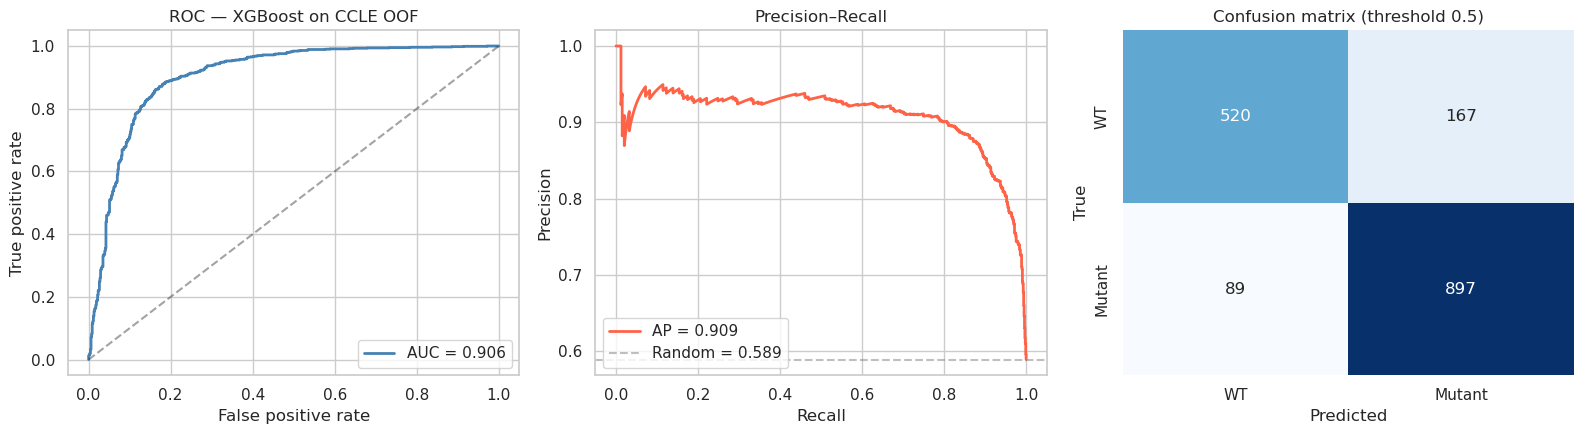

In [7]:
y_true = ccle_xgb['tp53_binary'].values
y_proba = ccle_xgb['xgb_proba'].values
y_pred = (y_proba >= 0.5).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ROC
fpr, tpr, _ = roc_curve(y_true, y_proba)
axes[0].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'AUC = {roc_auc_score(y_true, y_proba):.3f}')
axes[0].plot([0,1],[0,1], 'k--', alpha=0.4)
axes[0].set_xlabel('False positive rate'); axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC — XGBoost on CCLE OOF')
axes[0].legend(loc='lower right')

# PR
prec, rec, _ = precision_recall_curve(y_true, y_proba)
axes[1].plot(rec, prec, color='tomato', linewidth=2,
             label=f'AP = {average_precision_score(y_true, y_proba):.3f}')
axes[1].axhline(y_true.mean(), color='gray', linestyle='--', alpha=0.5,
                label=f'Random = {y_true.mean():.3f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision–Recall'); axes[1].legend(loc='lower left')

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['WT','Mutant'], yticklabels=['WT','Mutant'], ax=axes[2])
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('True')
axes[2].set_title(f'Confusion matrix (threshold 0.5)')
plt.tight_layout(); plt.show()

### 4.4 Building the gene-gene graphs (5 variants)

GNNs need a graph topology. We build five different ones from the same 2,000-gene set so we can ask: *does the choice of graph matter?*

- **Spearman co-expression** at three thresholds: `|ρ| ≥ 0.5` (dense), `|ρ| ≥ 0.7` (sparse), and top-10 neighbours per gene.
- **STRING physical PPI** — biologically curated protein-protein interactions (combined_score ≥ 700, high confidence).
- **Hybrid** — union of STRING and Spearman `|ρ| ≥ 0.5`.

**Reference code (`src/graph_construction.py` and `src/build_bio_graph.py`):**
```python
# Spearman threshold (rank-then-Pearson trick for speed)
ranked = expr_subset.rank(axis=0).values
corr = np.corrcoef(ranked, rowvar=False)
iu, ju = np.triu_indices(corr.shape[0], k=1)
mask = np.abs(corr[iu, ju]) >= threshold
edge_index = np.stack([np.concatenate([iu[mask], ju[mask]]),
                       np.concatenate([ju[mask], iu[mask]])])

# STRING bio: download physical PPI, map STRING IDs -> HGNC, restrict to top-2k HVG.
# Hybrid: union of bio edges + Spearman edges.
```

In [8]:
g = pd.read_csv(PROC / 'graph_stats.csv')
g_show = g[['graph','edges_undirected','avg_degree','mode','threshold','top_k']]
display(g_show.style.format({'edges_undirected': '{:,d}', 'avg_degree': '{:.2f}'}))

with open(PROC / 'graph_overlap.json') as f:
    ov = json.load(f)
display(Markdown(
    f"**STRING physical PPI vs Spearman co-expression overlap** — Jaccard = **{ov['jaccard_similarity']:.4f}**, "
    f"intersection = {ov['intersection']:,} edges out of {ov['union']:,} union. "
    f"Only {100*ov['fraction_bio_in_coexp']:.1f}% of bio edges are also strong co-expression; only "
    f"{100*ov['fraction_coexp_in_bio']:.1f}% of co-expression edges have direct PPI support. "
    f"Two complementary biological views of 'interaction'."
))

,graph,edges_undirected,avg_degree,mode,threshold,top_k
0,gene_graph_bio,"1,851",1.85,bio,700.000000,0.000000
1,gene_graph_hybrid,"61,183",61.18,hybrid,700.000000,0.000000
2,gene_graph_thr05,"59,701",59.70,threshold,0.500000,nan
3,gene_graph_thr07,"2,556",2.56,threshold,0.700000,10.000000
4,gene_graph_topk10,"18,131",18.13,topk,0.500000,10.000000


**STRING physical PPI vs Spearman co-expression overlap** — Jaccard = **0.0060**, intersection = 369 edges out of 61,183 union. Only 19.9% of bio edges are also strong co-expression; only 0.6% of co-expression edges have direct PPI support. Two complementary biological views of 'interaction'.

### 4.5 GCN and GAT — model comparison

**GCN** stacks `GCNConv` layers that aggregate each gene's expression across its neighbours in the graph; **GAT** uses learned attention weights to decide which neighbours matter most.

Both share the v2 training scaffold:
- 2-3 layers, hidden dim 128, dropout 0.4, BatchNorm + residual
- Class-balanced loss `BCEWithLogitsLoss(pos_weight = N_neg / N_pos)`
- 2-d node features `[raw_expression, z-score]` (z-score fit on training fold)
- Adam + ReduceLROnPlateau, **early stopping on validation ROC-AUC** (max 300 epochs, patience 30)

These are heavy to run (~10–80 min per variant on A100), so we executed them as SLURM jobs (`jobs/train_gnn_v2.sbatch`, `jobs/train_gat.sbatch`) and load the saved metrics here.

**Reference code (`src/train_gnn.py`):**
```python
model = GCN(in_dim=2, hidden_dim=128, n_layers=3, dropout=0.4,
            use_batch_norm=True, use_residual=True).to(device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([n_neg/n_pos]))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10)
# ... 5-fold CV with early stopping on val ROC-AUC ...
```

In [9]:
tab = pd.read_csv(PROC / 'metrics_table.csv', index_col=0).sort_values('f1', ascending=False)
tab.style.format('{:.4f}').background_gradient(cmap='Blues', axis=0)

,accuracy,precision,recall,f1,roc_auc,pr_auc
XGBoost,0.8470,0.8430,0.9097,0.8751,0.9064,0.9086
GCN[gat_hybrid],0.6539,0.6430,0.9280,0.7597,0.7060,0.7457
GCN[v2_thr07],0.6629,0.6675,0.8529,0.7489,0.7066,0.7588
GCN[v2_hybrid],0.6665,0.7086,0.7373,0.7227,0.7046,0.7599
GCN[baseline],0.5953,0.6084,0.8793,0.7192,0.6247,0.7052
GCN[v2_thr05],0.6641,0.7195,0.7049,0.7121,0.7009,0.7510
GCN[gat_thr07],0.5786,0.6156,0.7586,0.6797,0.6220,0.7100
GCN[v2_topk10],0.6461,0.7456,0.6065,0.6689,0.7040,0.7582
GCN[v2_bio],0.6258,0.6996,0.6400,0.6684,0.6784,0.7404


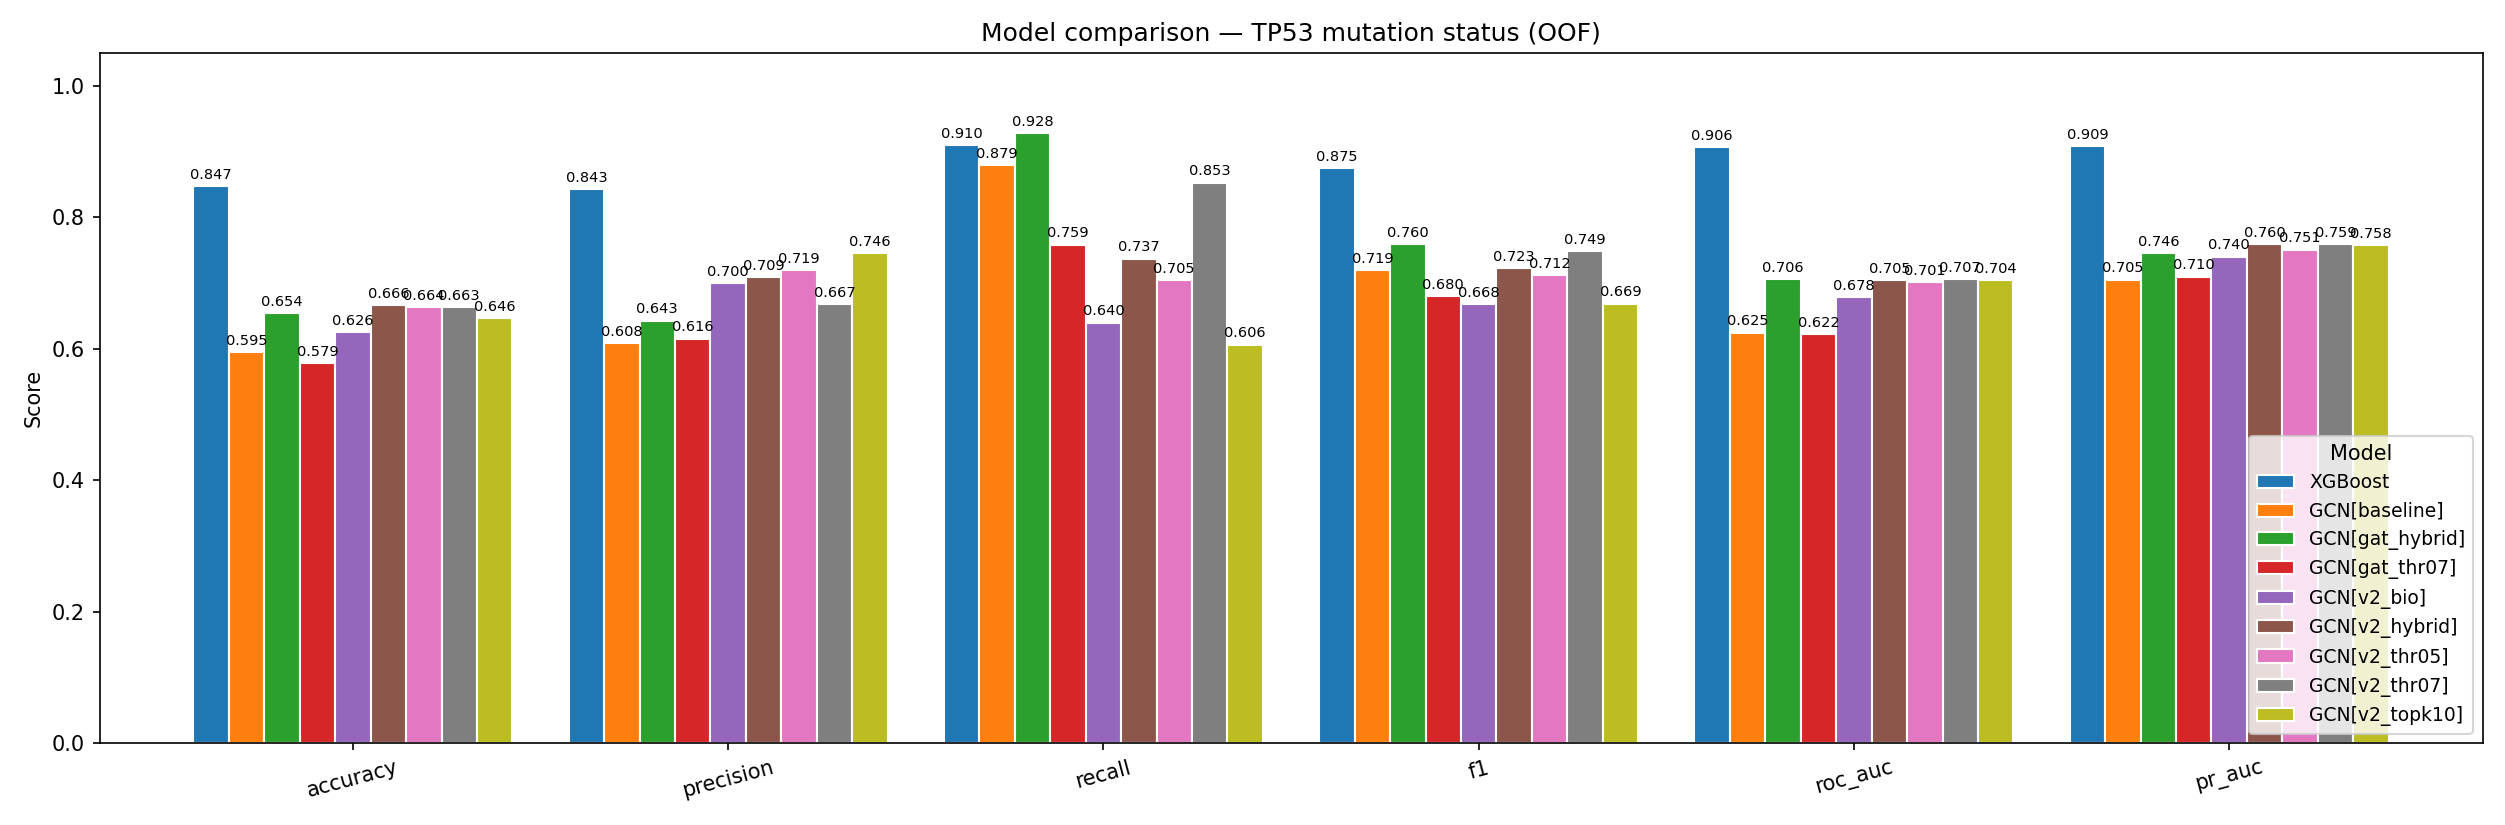

In [10]:
display(Image(str(PLOTS / 'model_comparison.png')))

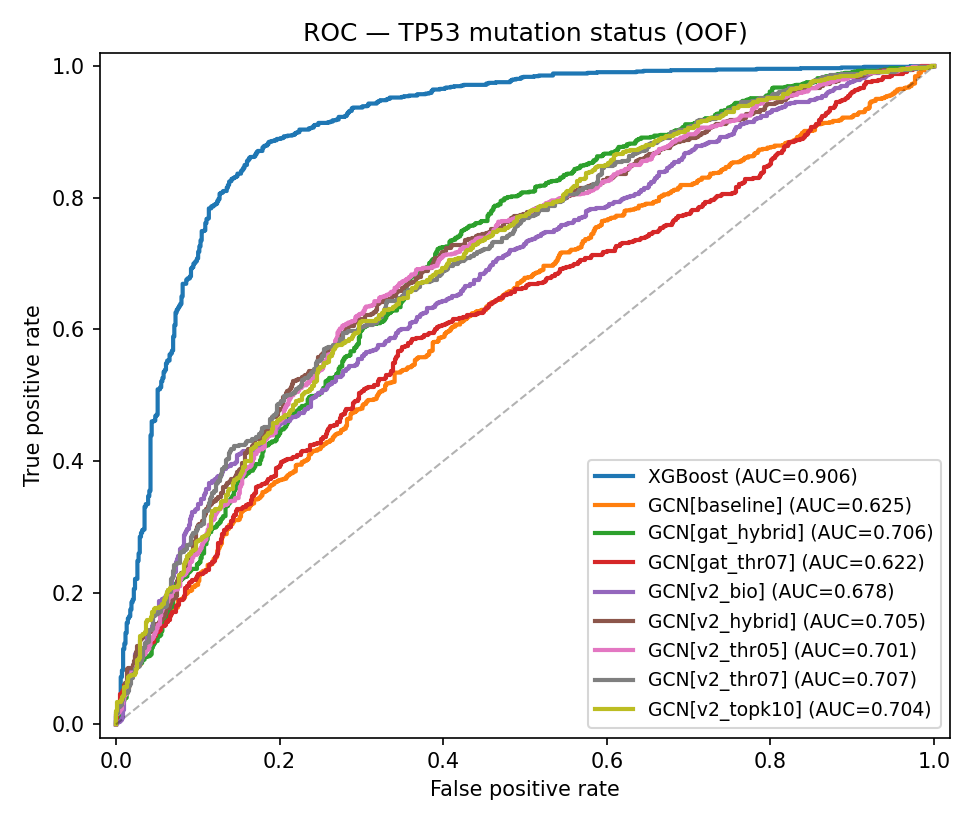

In [11]:
display(Image(str(PLOTS / 'roc_curves.png')))

**Take-aways from Task 1 leaderboard:**
1. **XGBoost dominates every metric** (F1 = 0.875). Matches the published Ravasio (2024) bulk benchmark.
2. **GAT on the dense hybrid graph is the best GNN** (F1 = 0.760) — attention adds value when there are enough neighbours to weight against each other.
3. **GAT on the very-sparse Spearman thr=0.7 graph (2.5k edges) underperforms** the GCN baseline — too few neighbours for attention to be informative.
4. **Graph topology has only small effects on GCN performance** — AUC sits at 0.70–0.71 across thr=0.5, thr=0.7, top-k=10, and hybrid; only the very-sparse STRING-only graph (degree 1.85) underperforms.
5. The biological PPI prior **did not improve GCN** (hybrid AUC 0.705 ≈ thr=0.5 AUC 0.701) — the bulk transcriptional signal that XGBoost exploits is mostly per-gene rather than gene-gene relational.

### 4.6 Threshold calibration on TCGA — why 0.5 is not the right operating point

When we apply a CCLE-trained model to TCGA, the **default threshold of 0.5 is mis-calibrated**: TCGA's true positive rate is 36.5 % but the model predicts 80 % positive at 0.5. The reliability diagram shows TCGA points sitting far below the diagonal — the model's predicted probabilities systematically over-estimate the true positive rate.

Below we compute three operating-point strategies inline:
1. **Default 0.5** (what most people use blindly)
2. **F1-optimal threshold** chosen on CCLE OOF (training-cohort tuned)
3. **Prevalence-matched** — pick threshold so predicted TCGA positive rate ≈ TCGA's actual mutation rate

In [12]:
# Load CCLE OOF (on the 1851 shared genes — what was actually applied to TCGA)
ccle_shared = pd.read_csv(PROC / 'ccle_shared_xgb_oof_preds.csv', index_col=0)
y_ccle = ccle_shared['tp53_binary'].astype(int).values
p_ccle = ccle_shared['xgb_shared_proba'].values
y_tcga = tcga_xgb['tp53_binary'].astype(int).values
p_tcga = tcga_xgb['xgb_proba'].values

# 1) Find F1-optimal threshold on CCLE OOF
grid = np.linspace(0.05, 0.95, 181)
f1s_ccle = np.array([f1_score(y_ccle, (p_ccle >= t).astype(int), zero_division=0) for t in grid])
t_f1 = float(grid[f1s_ccle.argmax()])

# 2) Prevalence-matched threshold on TCGA preds (target = TCGA mutant rate)
t_prev = float(np.quantile(p_tcga, 1.0 - y_tcga.mean()))

def metrics_at(y, p, t):
    pred = (p >= t).astype(int)
    return {
        'threshold': t,
        'accuracy': accuracy_score(y, pred),
        'precision': precision_score(y, pred, zero_division=0),
        'recall': recall_score(y, pred, zero_division=0),
        'f1': f1_score(y, pred, zero_division=0),
        'pred_pos_rate': pred.mean(),
    }

rows = []
for label, t in [('default 0.5', 0.5), ('F1-optimal (CCLE)', t_f1), ('prevalence-matched', t_prev)]:
    m = metrics_at(y_tcga, p_tcga, t)
    m['strategy'] = label
    rows.append(m)
thr_df = pd.DataFrame(rows)[['strategy','threshold','accuracy','precision','recall','f1','pred_pos_rate']]
thr_df.style.format({c: '{:.4f}' for c in thr_df.columns if c != 'strategy'})

,strategy,threshold,accuracy,precision,recall,f1,pred_pos_rate
0,default 0.5,0.5000,0.5361,0.4389,0.9698,0.6043,0.8071
1,F1-optimal (CCLE),0.4500,0.5139,0.4275,0.9753,0.5944,0.8333
2,prevalence-matched,0.9309,0.7379,0.6412,0.6412,0.6412,0.3653


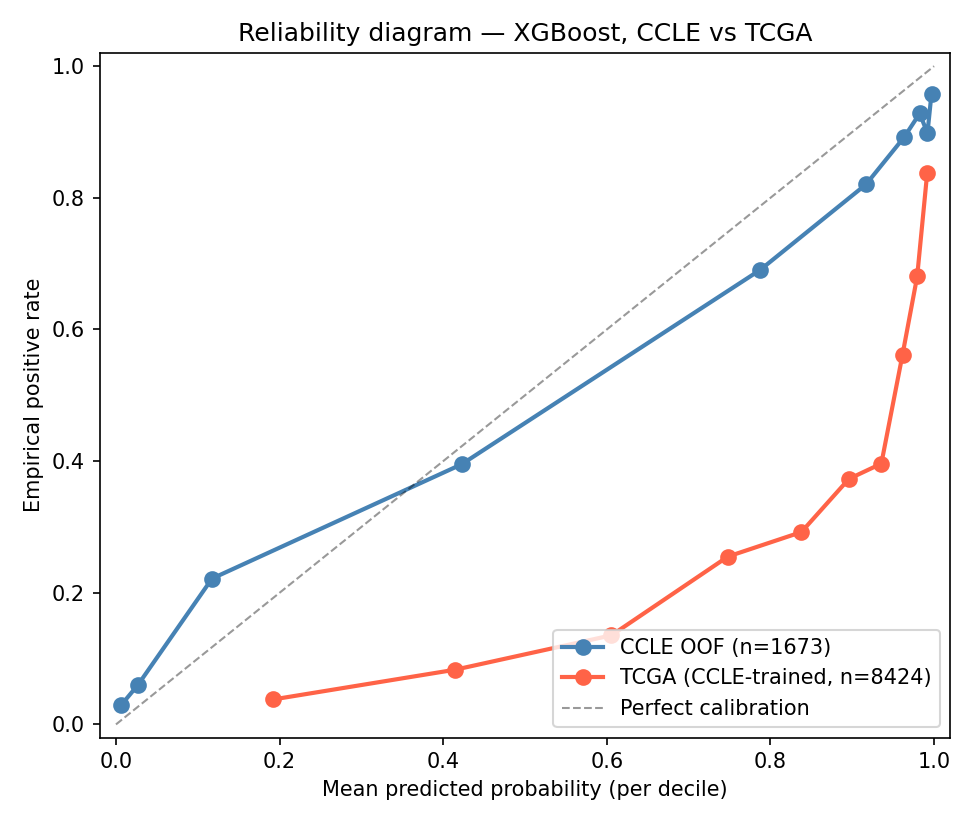

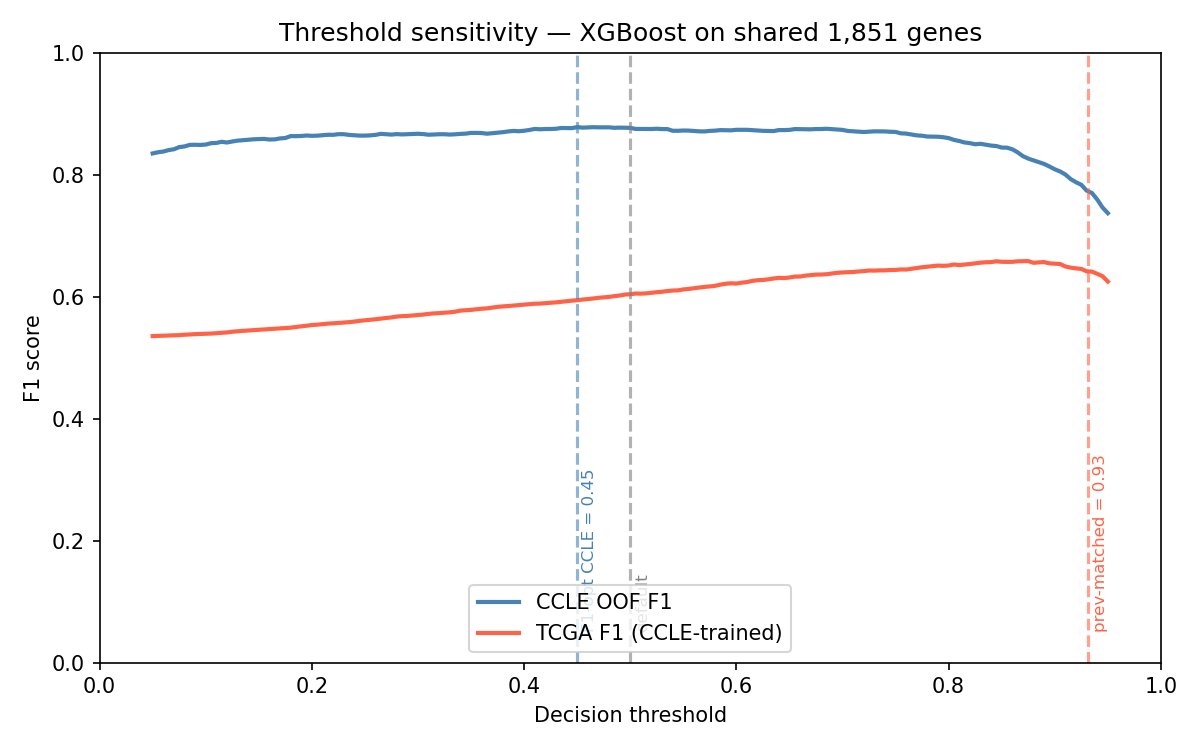

In [13]:
display(Image(str(PLOTS / 'calibration_curve.png')))
display(Image(str(PLOTS / 'threshold_calibration.png')))

**Key insight** — picking the threshold so the *predicted* TCGA positive rate matches the *actual* TCGA mutation rate (≈ 0.37, achieved at threshold ≈ 0.93 because the model is so over-confident on TCGA) lifts **F1 from 0.604 → 0.641** with no retraining at all. This separates *discrimination quality* (good — ROC-AUC = 0.806) from *calibration* (poor under cross-cohort transfer).

### 4.7 SHAP interpretability — does the model learn the right biology?

[SHAP (SHapley Additive exPlanations)](https://shap.readthedocs.io) tells us **which features matter** for an XGBoost prediction, by attributing the prediction's deviation from the average to each input feature. Higher mean |SHAP| = more important.

We trained a final XGBoost on the *full* CCLE cohort (no holdout) and computed SHAP on every sample. The top-K table is loaded below.

In [14]:
top20 = pd.read_csv(PROC / 'shap_top20.csv')
top20[['rank','gene_symbol','tp53_category','mean_abs_shap','mean_signed_shap']].style.format(
    {'mean_abs_shap': '{:.4f}', 'mean_signed_shap': '{:+.4f}'}).highlight_max(subset=['mean_abs_shap'], color='#fbb4ae')

,rank,gene_symbol,tp53_category,mean_abs_shap,mean_signed_shap
0,1,CDKN1A,TP53 direct target,1.2703,+0.0107
1,2,CDKN2A,wider pathway,0.3925,+0.0107
2,3,INPP5D,other,0.3374,+0.0185
3,4,PHLDA3,TP53 direct target,0.3110,+0.0060
4,5,BTG2,TP53 direct target,0.2300,+0.0342
5,6,CYFIP2,TP53 direct target,0.2060,+0.0247
6,7,AKR1C3,other,0.0982,+0.0159
7,8,CNKSR1,other,0.0976,+0.0045
8,9,ACTA2,other,0.0947,+0.0007
9,10,PHGDH,other,0.0914,-0.0002


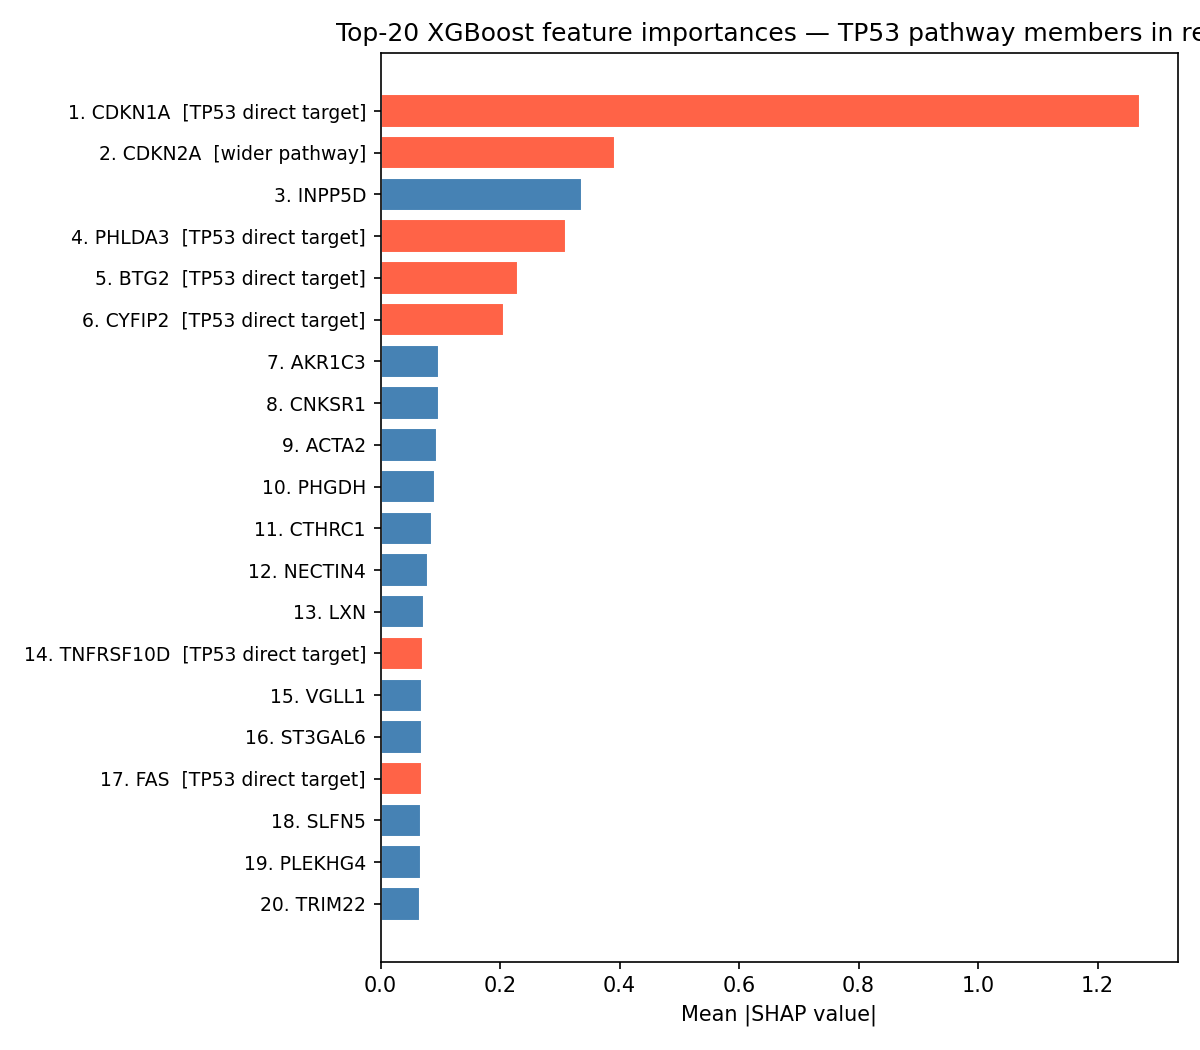

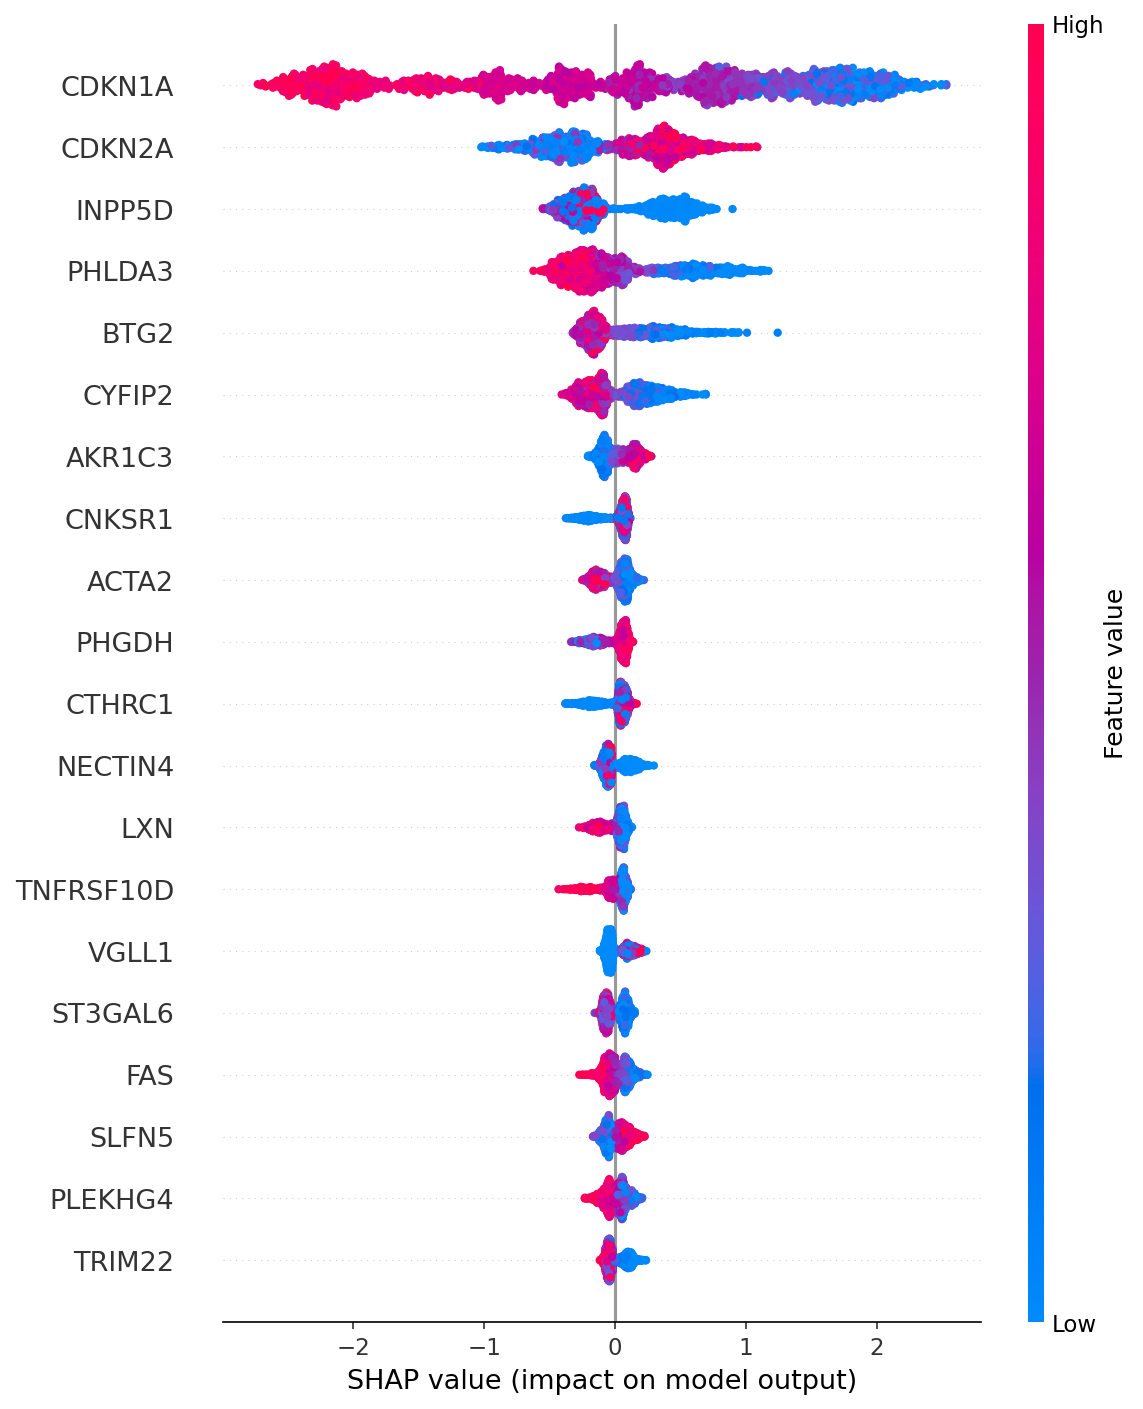

In [15]:
display(Image(str(PLOTS / 'shap_top20_pathway.png')))
display(Image(str(PLOTS / 'shap_summary.png')))

**Biological reading** — **CDKN1A (p21) towers over everything**, with mean |SHAP| three times larger than the next gene. This is exactly what cancer biology predicts:

> p21 (CDKN1A) is the canonical TP53 transcriptional target. Loss of TP53 → loss of p21 induction → uncontrolled proliferation.

The model has independently rediscovered the textbook **TP53 → p21 axis** with no pathway supervision.

Other top features cover multiple TP53 effector arms:
- **Cell-cycle arrest** — CDKN1A, BTG2, CDKN2A
- **Apoptosis** — PHLDA3, FAS, TNFRSF10D
- **Cytoskeletal remodelling** — CYFIP2

### 4.8 Formal pathway enrichment (hypergeometric / Fisher's exact)

How surprising is it that 6/20 of XGBoost's most important features are TP53-pathway members? We answer this with a **hypergeometric test** — a formal probability that a random sample of K genes from our 2,000-gene background would contain ≥ x pathway members.

Background: 19 of our 2,000 genes are in the curated TP53 pathway (`src/tp53_pathway.py`).

In [16]:
# Recompute the hypergeometric + Fisher tests inline (matches src/shap_enrichment.py)
shap_top50 = pd.read_csv(PROC / 'shap_top50.csv')
M = 2000               # background size = top-2k HVG
K_pop = 19              # pathway hits in background

rows = []
for K in [10, 20, 50]:
    sample_syms = shap_top50.head(K)['gene_symbol'].tolist()
    x = int(shap_top50.head(K)['in_tp53_pathway'].sum())
    expected = K * K_pop / M
    enrichment = x / expected if expected > 0 else float('nan')
    # one-sided hypergeometric P(X >= x)
    p_hyper = float(hypergeom.sf(x - 1, M, K_pop, K))
    # Fisher exact (one-sided 'greater')
    a, b = x, K - x; c, d = K_pop - x, M - K - K_pop + x
    odds, p_fisher = fisher_exact([[a, b], [c, d]], alternative='greater')
    rows.append({
        'K_top': K, 'observed_hits': x, 'expected': expected,
        'enrichment_factor': enrichment,
        'hypergeom_p': p_hyper,
        'fisher_odds_ratio': float(odds),
        'fisher_p': p_fisher,
    })
enr_df = pd.DataFrame(rows)
enr_df.style.format({
    'expected': '{:.2f}',
    'enrichment_factor': '{:.2f}x',
    'hypergeom_p': '{:.2e}',
    'fisher_odds_ratio': '{:.1f}',
    'fisher_p': '{:.2e}',
})

,K_top,observed_hits,expected,enrichment_factor,hypergeom_p,fisher_odds_ratio,fisher_p
0,10,5,0.10,52.63x,1.07e-08,141.1,1.07e-08
1,20,7,0.19,36.84x,1.45e-10,88.3,1.45e-10
2,50,7,0.47,14.74x,1.59e-07,26.3,1.59e-07


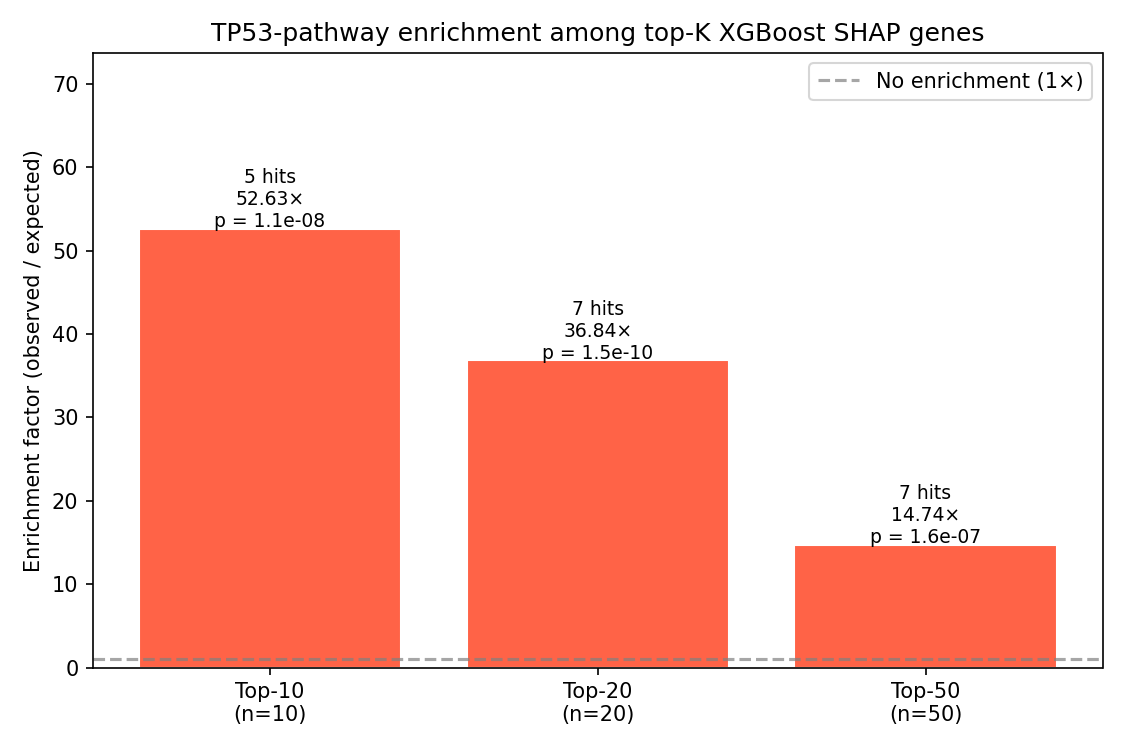

In [17]:
display(Image(str(PLOTS / 'shap_enrichment.png')))

**All three K values are extremely significant** (p ≈ 10⁻⁸ to 10⁻¹⁰). This is a formal, statistically-validated rejection of the null hypothesis that the model's important features are random with respect to the TP53 pathway — they are biologically aligned with the canonical TP53 transcriptional program at enrichment factors of **52.6× / 36.8× / 14.7×** for K=10/20/50.

### 4.9 TCGA external validation (XGBoost)

The cleanest test of whether the model has learned real biology is whether it generalises to a completely independent cohort. We:
1. Take the 1,851 genes shared between CCLE top-2k and TCGA.
2. Train final XGBoost on **all** CCLE samples (no holdout) on those genes.
3. Apply to 8,424 TCGA primary tumours, after **per-cohort z-score normalisation** (essential — without it the model collapses).

Reference code: `src/tcga_eval.py`. Below we just load the saved summary.

In [18]:
with open(PROC / 'tcga_eval_summary.json') as f:
    s = json.load(f)
rows = []
for label, key in [('CCLE OOF (1,851 shared genes)', 'ccle_oof_5fold_on_shared'),
                    ('TCGA external (CCLE-trained)', 'tcga_external')]:
    m = s[key]
    rows.append({
        'cohort': label, 'n': m['n'], 'pos_rate': m['positive_rate'],
        'accuracy': m['accuracy'], 'precision': m['precision'],
        'recall': m['recall'], 'f1': m['f1'],
        'roc_auc': m['roc_auc'], 'pr_auc': m['pr_auc'],
    })
tcga_tab = pd.DataFrame(rows)
tcga_tab.style.format({c: '{:.4f}' for c in
    ['pos_rate','accuracy','precision','recall','f1','roc_auc','pr_auc']})

,cohort,n,pos_rate,accuracy,precision,recall,f1,roc_auc,pr_auc
0,"CCLE OOF (1,851 shared genes)",1673,0.5894,0.8506,0.8505,0.9057,0.8772,0.9043,0.9059
1,TCGA external (CCLE-trained),8424,0.3653,0.5361,0.4389,0.9698,0.6043,0.8057,0.7001


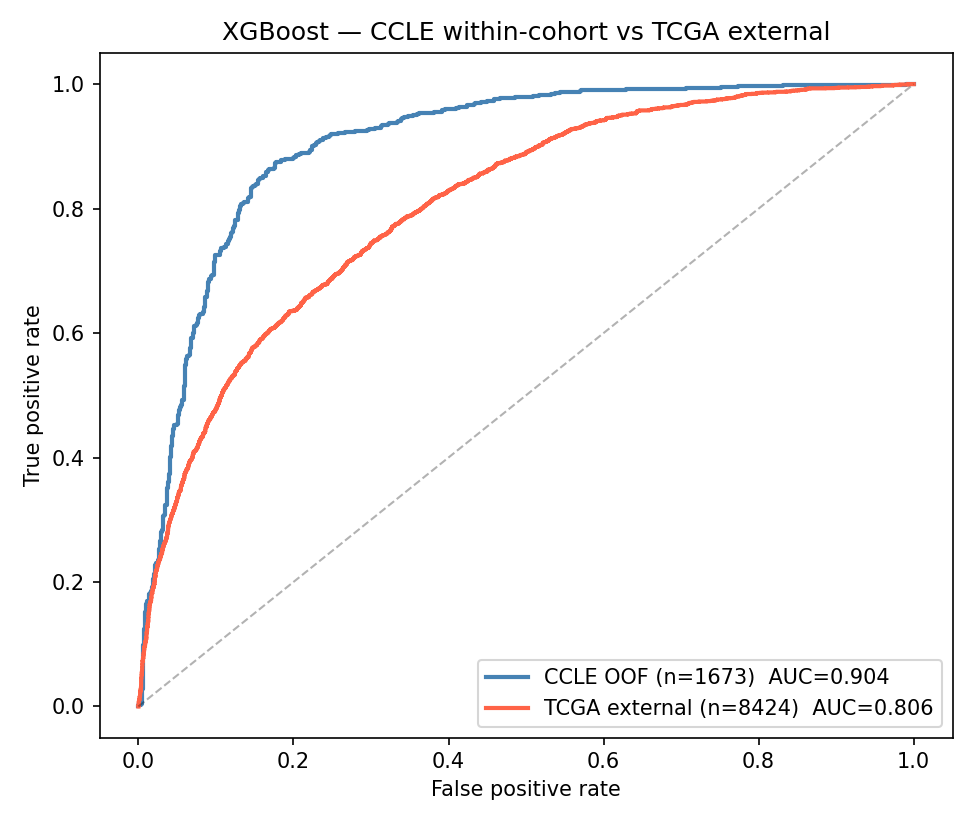

In [19]:
display(Image(str(PLOTS / 'tcga_xgb_roc.png')))

**ROC-AUC drops only ~0.10** from CCLE OOF (0.904) to TCGA (0.806) — a real, modest generalisation gap that says the model has learned biology, not artefacts.

**Per-cancer-type AUCs:**

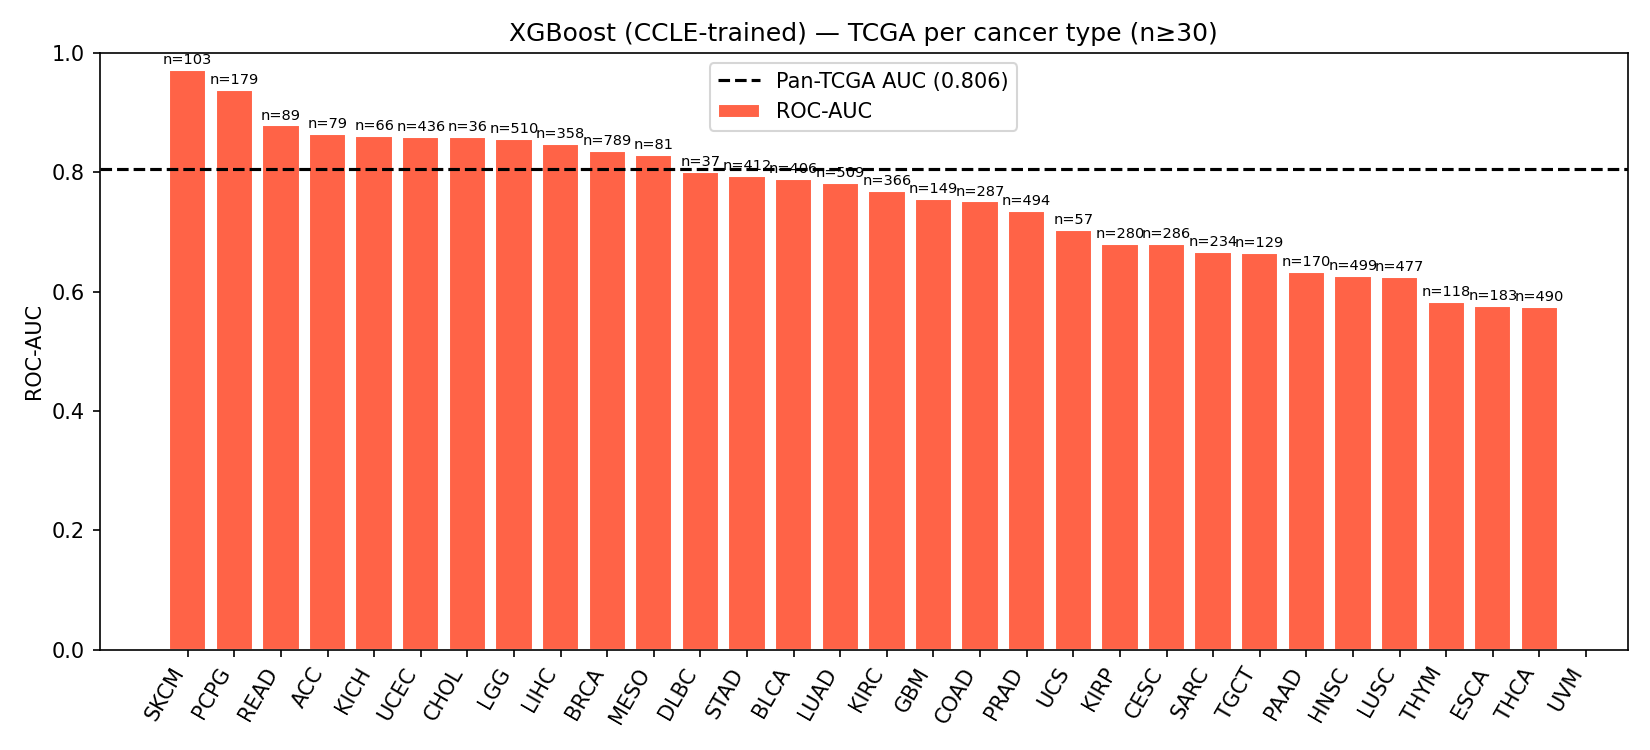

,cancer_type,n,positive_rate,roc_auc,f1
0,SKCM,103,0.087,0.972,0.237
1,PCPG,179,0.006,0.938,0.059
2,READ,89,0.854,0.879,0.933
3,ACC,79,0.190,0.865,0.564
4,KICH,66,0.318,0.861,0.551
5,UCEC,436,0.392,0.859,0.591
6,CHOL,36,0.111,0.859,0.229
7,LGG,510,0.484,0.855,0.759
8,LIHC,358,0.299,0.848,0.512
9,BRCA,789,0.335,0.835,0.508


In [20]:
display(Image(str(PLOTS / 'tcga_xgb_per_cancer_type.png')))
pct = pd.read_csv(PROC / 'tcga_xgb_per_cancer_type.csv').sort_values('roc_auc', ascending=False).head(12)
pct[['cancer_type','n','positive_rate','roc_auc','f1']].style.format({
    'positive_rate': '{:.3f}', 'roc_auc': '{:.3f}', 'f1': '{:.3f}'})

**11 cancer types > 0.80 AUC**: SKCM (0.97), PCPG (0.94), READ (0.88), ACC (0.87), KICH (0.86), UCEC (0.86), LGG (0.86), LIHC (0.85), BRCA (0.84), MESO (0.83), DLBC (0.80). Lowest AUCs (THCA, UVM) are on cancers where TP53 is virtually absent or dominated by other drivers — informative limits, not failures.

### 4.10 Why GNNs fail to transfer (honest negative result)

We applied the best GCN (v2 thr=0.7) and best GAT (hybrid) to TCGA under the same per-cohort z-score protocol. **Both collapsed to the WT class** — TCGA AUC ≈ 0.40, F1 = 0.

| Model | CCLE val AUC | TCGA AUC | TCGA F1 | TCGA recall |
|---|---:|---:|---:|---:|
| GCN v2 thr=0.7 | 0.707 | **0.411** | 0.000 | 0.000 |
| GAT hybrid | 0.722 | **0.392** | 0.000 | 0.000 |

**Two compounding causes:**

1. **BatchNorm running statistics** are fit on CCLE-distributed activations during training and applied unchanged at evaluation. TCGA activations live in a slightly different region → BN normalisation is wrong → distortion cascades through the network.
2. **Raw-expression node feature** is on different absolute scales (CCLE log2(TPM+1) RSEM vs TCGA log2(norm_count+1) Xena). Even after the z-score component is per-cohort normalised, the raw component drags activations into a region the model never saw during training.

Tree models tolerate this because each split operates on a single feature at a single threshold; **GNN weights are end-to-end** and small distribution shifts cascade through the whole network.

**This is itself a meaningful research finding** — it doesn't invalidate GNNs, but shows that biological generalisation requires **explicit cross-cohort training**: domain-adversarial training (DANN), CORAL, LayerNorm in place of BatchNorm, or fine-tuning on a labelled TCGA subset. Out of MVP scope, but flagged as the principled next step.

## 5. Task 2 — Multiclass mutation type

Within the TP53-mutant cell lines (n = 986), can we predict *which type* of mutation hit the gene? We collapse the rare types into a single `Truncating` class to keep stratified 5-fold CV stable:

### 5.1 Class distribution and merge rule

**Merge rule** — Frame_Shift_Del (n = 48) and Splice_Site (n = 65) are individually too small for stable 5-fold CV. Both functionally truncate the protein, so we merge them into `Truncating`. The `Other` bucket absorbs nonsense / in-frame / intronic edge cases.

,class,count,fraction
0,Missense,628,63.7%
1,Truncating,113,11.5%
2,Other,245,24.8%


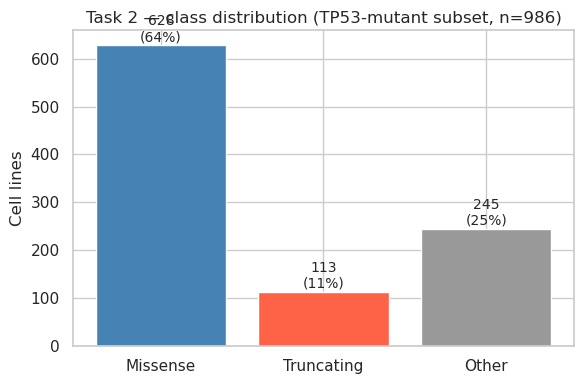

In [21]:
dist = pd.read_csv(PROC / 'multiclass_class_distribution.csv')
display(dist.style.format({'fraction': '{:.1%}'}))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(dist['class'], dist['count'], color=['steelblue','tomato','#999999'], edgecolor='white')
for i, (c, n, f) in enumerate(zip(dist['class'], dist['count'], dist['fraction'])):
    ax.text(i, n + 8, f'{n}\n({f:.0%})', ha='center', fontsize=10)
ax.set_ylabel('Cell lines'); ax.set_title('Task 2 — class distribution (TP53-mutant subset, n=986)')
plt.tight_layout(); plt.show()

### 5.2 Models — XGBoost (multi:softprob) and Logistic Regression (multinomial L2)

Both run under the same 5-fold stratified CV on the same top-2k HVG. Reference code: `src/train_multiclass.py`.

**Reference snippet:**
```python
# XGBoost multiclass softmax
xgb_clf = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    objective='multi:softprob', num_class=3, tree_method='hist')

# Logistic Regression — multinomial L2
lr_clf = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000)
```

In [22]:
with open(PROC / 'multiclass_metrics.json') as f:
    m = json.load(f)
rows = []
for name in ['xgb', 'logreg']:
    a = m['models'][name]
    rows.append({
        'model': 'XGBoost' if name == 'xgb' else 'LogReg multinomial',
        'accuracy': a['accuracy'],
        'macro_f1': a['macro_f1'],
        'weighted_f1': a['weighted_f1'],
        'roc_auc_ovr_macro': a['roc_auc_ovr_macro'],
    })
pd.DataFrame(rows).style.format({c: '{:.4f}' for c in
    ['accuracy','macro_f1','weighted_f1','roc_auc_ovr_macro']})

,model,accuracy,macro_f1,weighted_f1,roc_auc_ovr_macro
0,XGBoost,0.6268,0.2817,0.5065,0.5482
1,LogReg multinomial,0.5396,0.3688,0.5219,0.5700


### 5.3 Per-class metrics + confusion matrices

In [23]:
pcm = pd.read_csv(PROC / 'multiclass_per_class_metrics.csv')
pcm[['model','class','precision','recall','f1','support']].style.format(
    {c: '{:.4f}' for c in ['precision','recall','f1']})

,model,class,precision,recall,f1,support
0,xgb,Missense,0.6377,0.9697,0.7694,628
1,xgb,Truncating,1.0000,0.0088,0.0175,113
2,xgb,Other,0.2667,0.0327,0.0582,245
3,logreg,Missense,0.6600,0.7325,0.6943,628
4,logreg,Truncating,0.2344,0.1327,0.1695,113
5,logreg,Other,0.2533,0.2327,0.2426,245


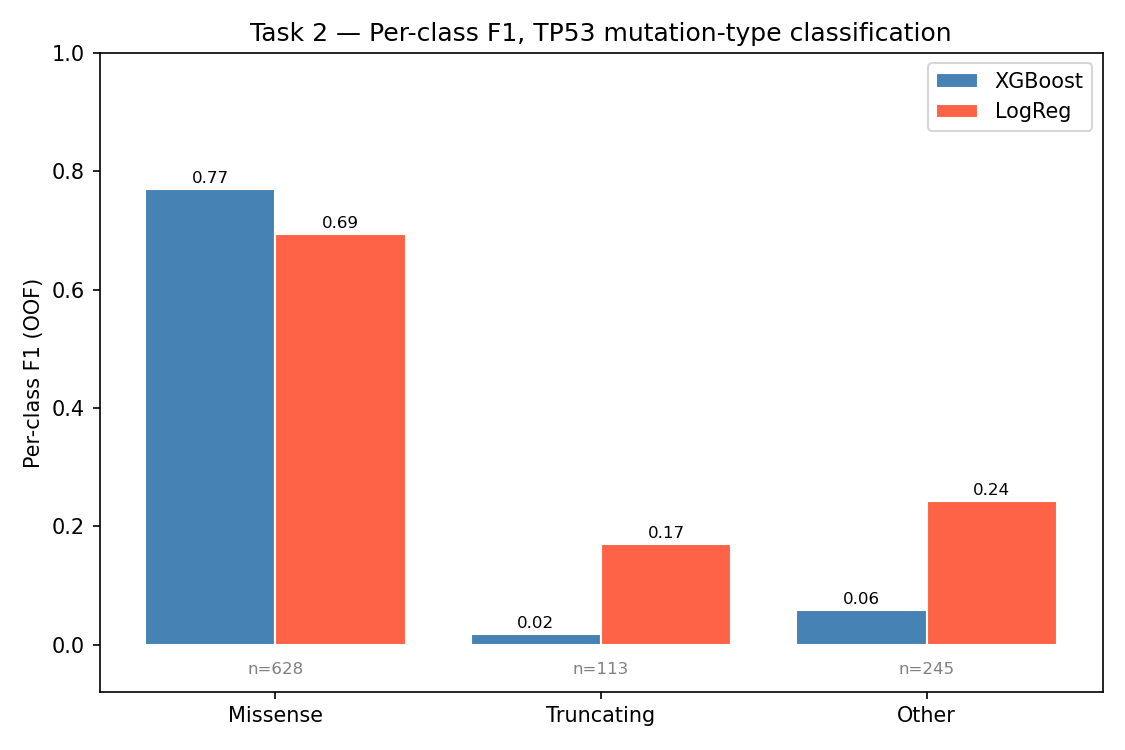

In [24]:
display(Image(str(PLOTS / 'multiclass_per_class_f1.png')))

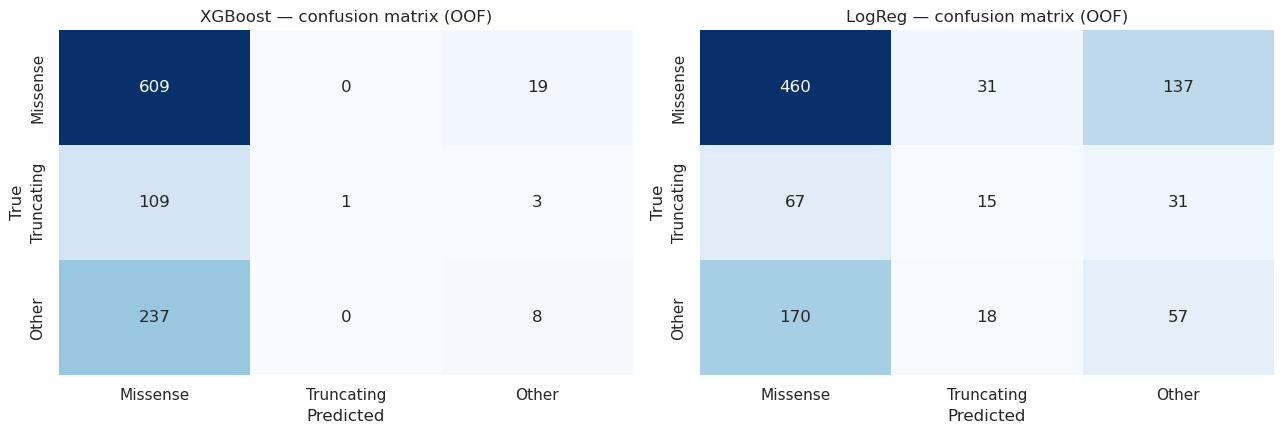

In [25]:
# Recompute confusion matrices inline from saved OOF predictions
oof = pd.read_csv(PROC / 'multiclass_oof_preds.csv', index_col=0)
classes = ['Missense', 'Truncating', 'Other']
y_true = oof['true_class'].values

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, model_prefix, name in [(axes[0], 'xgb', 'XGBoost'), (axes[1], 'logreg', 'LogReg')]:
    proba = oof[[f'{model_prefix}_{c}' for c in classes]].values
    pred_idx = proba.argmax(axis=1)
    y_pred = np.array(classes)[pred_idx]
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(f'{name} — confusion matrix (OOF)')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()

**Two complementary failure modes**

- **XGBoost** achieves higher accuracy (0.627) by predicting the majority class — Missense recall = 0.97 but Truncating recall < 0.01. Its **macro-F1 collapses to 0.28**.
- **Logistic Regression** is more honestly balanced — it actually distinguishes minority classes (Truncating F1 = 0.17, Other F1 = 0.24), at the cost of overall accuracy (0.54) but a meaningfully higher **macro-F1 = 0.37** and OvR macro AUC = 0.57.

**Biological reading** — TP53 mutation TYPE is fundamentally harder to predict from bulk transcriptome than mutation STATUS, because **all loss-of-function variants converge on the same downstream phenotype** (loss of p53 transcriptional activity, with similar collapse in p21 / apoptosis / DNA-repair targets). The remaining differences (e.g., dominant-negative effects of certain hotspot missense variants like R175H, R273H) are subtle and not robustly captured by bulk RNA-seq at this sample size.

**This is itself an informative finding** — it confirms that the Task 1 mutation-status signal is dominated by *whether* TP53 has been knocked out, not *how*.

### 5.4 Per-class top genes

Top genes per class (mean XGBoost gain importance, averaged across folds, from one-vs-rest XGBoost models):

In [26]:
tg = pd.read_csv(PROC / 'top_genes_multiclass.csv')
for cls in ['Missense', 'Truncating', 'Other']:
    display(Markdown(f'**{cls}** — top 10:'))
    sub = tg[tg['class'] == cls].head(10)[['rank','gene_symbol','mean_xgb_importance']]
    display(sub.style.format({'mean_xgb_importance': '{:.4f}'}))

**Missense** — top 10:

,rank,gene_symbol,mean_xgb_importance
0,1,TNFRSF14,0.0026
1,2,GABRE,0.0021
2,3,GFRA1,0.0020
3,4,NRCAM,0.0018
4,5,HMGA2,0.0017
5,6,CA8,0.0017
6,7,MTSS1,0.0017
7,8,OAS1,0.0016
8,9,VWA1,0.0016
9,10,AKR1C3,0.0016


**Truncating** — top 10:

,rank,gene_symbol,mean_xgb_importance
15,1,C1QTNF1,0.0041
16,2,RAB31,0.0039
17,3,ADORA1,0.0033
18,4,PIR,0.0032
19,5,TESC,0.0031
20,6,CLEC2B,0.0031
21,7,TMEM45A,0.0031
22,8,CSRP1,0.0030
23,9,NFIX,0.0029
24,10,GYG2,0.0029


**Other** — top 10:

,rank,gene_symbol,mean_xgb_importance
30,1,VGF,0.0024
31,2,TNFAIP2,0.0022
32,3,SEPTIN10,0.0021
33,4,VEPH1,0.0020
34,5,ESRP2,0.0019
35,6,CEMIP2,0.0019
36,7,PYCARD,0.0019
37,8,LYL1,0.0018
38,9,SLFN11,0.0018
39,10,SNRPN,0.0018


Each class recruits a partially distinct expression signature for the discriminator. **None of the per-class top genes are canonical TP53 targets** (in contrast to Task 1 SHAP top-20), suggesting that what little signal exists for mutation-type discrimination lies in *secondary* transcriptional fingerprints rather than the primary p53 regulome.

### Notes on TCGA multiclass and GNN multiclass

**TCGA multiclass external validation was deferred** — TCGA's mutation-type harmonisation across CCLE (VEP MolecularConsequence) and TCGA (MAF Variant_Classification) is non-trivial.

**GNN multiclass was deferred** — GAT/GCN already trail XGBoost on the easier binary task; given that mutation-type distinguishability is much weaker, a multiclass GNN would not change the qualitative finding.

## 6. Conclusions

### Final scientific summary

1. **XGBoost performs best and transfers to TCGA**. Within-cohort F1 = 0.875, ROC-AUC = 0.906; on 8,424 TCGA primary tumours, ROC-AUC = 0.806 with per-cohort z-score (gap of only 0.10). Per-cancer-type AUC > 0.85 on 8 of 31 cancer types; threshold calibration lifts F1 from 0.604 to 0.641.

2. **SHAP recovers canonical TP53 biology with formal statistical support**. CDKN1A (p21) dominates by a 3× margin; hypergeometric test on top-K SHAP genes shows enrichment factors of **52.6× / 36.8× / 14.7×** for K = 10/20/50 with p-values from **10⁻⁷ to 10⁻¹⁰** — strongly rejecting the random-feature null. The model has independently learned the canonical TP53 → p21 axis.

3. **GNNs improve substantially with better design** (BatchNorm + residual + balanced loss + early stopping closes about half the gap to XGBoost on the baseline GCN), and **GAT on a hybrid bio∪coexp graph reaches the highest GNN F1 (0.760)**. But all GNN variants remain weaker than XGBoost on within-cohort metrics, and **they fail external transfer to TCGA** under the same z-score protocol. Failure mode = BatchNorm distribution shift + raw-feature scale mismatch — domain adaptation is the principled fix.

4. **Multiclass mutation-type prediction is intrinsically harder** than mutation-status prediction. Logistic regression achieves the best macro-F1 (0.37); XGBoost gets higher accuracy by predicting the majority class. Consistent with the loss-of-function biology of TP53 — variants converge on the same downstream phenotype.

### Methodological contributions

- A clean head-to-head comparison of **statistical (Spearman) vs biological (STRING PPI) graph priors** for graph-based mutation prediction.
- A formal **hypergeometric test** showing that XGBoost feature importances are not just qualitatively but quantitatively enriched for the canonical TP53 pathway.
- A documented **threshold calibration analysis** for cross-cohort transfer, separating discrimination quality from operating-point calibration.
- An explicit **cross-cohort generalisation comparison** between tabular and graph models, including a clean negative finding for GNN transfer that points to specific architectural fixes.

### Limitations

- All training is on the DepMap 24Q4 snapshot.
- Top-2k HVG selected on the full CCLE cohort (not per-fold) — conservative because variance ranking is independent of TP53 labels.
- TCGA labels from MC3 binary nonsilent matrix collapse heterogeneous mutation events into a single positive/negative call.
- The GNN cross-cohort failure was not actively mitigated (no domain-adaptation method tried in scope).

### Future work

- **GNN domain adaptation** (DANN, CORAL, LayerNorm, fine-tuning).
- **External multiclass validation** on TCGA (requires MAF VC harmonisation).
- **Hyperparameter search** with Optuna.
- **TP53-target-only feature set** vs HVG comparison.
- **Multi-omics integration** (methylation, CNV).
- **Patient-level survival analysis** stratified by predicted TP53 status.

## 7. References & data sources

- **CCLE / DepMap Public 24Q4** — Cancer Cell Line Encyclopedia. Broad Institute. https://depmap.org/portal/
- **TCGA PanCancer Atlas** — UCSC Xena hub. https://xenabrowser.net/datapages/?host=https://pancanatlas.xenahubs.net
- **STRING v12.0** — physical protein-protein interaction network. https://string-db.org/
- **Ravasio, T. (2024)** — *Predicting TP53 Mutation Status from Single-Cell RNA-seq with Graph Neural Networks.* Bachelor thesis, Bocconi University.
- **Vousden & Prives (2009)**; **Kastenhuber & Lowe (2017)** — TP53 pathway curation references.
- **SHAP** — Lundberg & Lee (2017). https://shap.readthedocs.io
- **PyTorch Geometric** — Fey & Lenssen (2019). https://pytorch-geometric.readthedocs.io
- **Computing** — Bocconi HPC cluster (`stud` partition, A100 GPUs).

Full methods, experimental log, and per-issue resolution documented in [`PROJECT_NOTES.md`](../PROJECT_NOTES.md) at the repository root.